In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter


In [ ]:
#read of dataphram
df=pd.read_csv('../../data/raw/dna-classification-dataset/synthetic_dna_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        3000 non-null   object 
 1   Sequence         3000 non-null   object 
 2   GC_Content       3000 non-null   float64
 3   AT_Content       3000 non-null   float64
 4   Sequence_Length  3000 non-null   int64  
 5   Num_A            3000 non-null   int64  
 6   Num_T            3000 non-null   int64  
 7   Num_C            3000 non-null   int64  
 8   Num_G            3000 non-null   int64  
 9   kmer_3_freq      3000 non-null   float64
 10  Mutation_Flag    3000 non-null   int64  
 11  Class_Label      3000 non-null   object 
 12  Disease_Risk     3000 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 304.8+ KB


In [ ]:
#overview of data
def overview(df):
    '''
    Erstelle einen Überblick über einige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        overview: Überblick über einige Eigenschaften der Spalten eines DataFrames.
    '''
    overview=display(pd.DataFrame({'dtype': df.dtypes,
                          'total': df.count(),
                          'missing values(n)': df.isna().sum(),
                          'missing values(%)': df.isna().mean()*100,
                          'number of uniques': df.nunique(),
                          'uniques': [df[col].unique() for col in df.columns]
                         }))
    return overview
    
overview(df)

,dtype,total,missing values(n),missing values(%),number of uniques,uniques
Sample_ID,object,3000,0,0.0,3000,"[SAMPLE_1, SAMPLE_2, SAMPLE_3, SAMPLE_4, SAMPL..."
Sequence,object,3000,0,0.0,3000,[CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCC...
GC_Content,float64,3000,0,0.0,33,"[50.0, 45.0, 51.0, 55.0, 46.0, 62.0, 42.0, 59...."
AT_Content,float64,3000,0,0.0,33,"[50.0, 55.0, 49.0, 45.0, 54.0, 38.0, 58.0, 41...."
Sequence_Length,int64,3000,0,0.0,1,[100]
Num_A,int64,3000,0,0.0,30,"[22, 27, 26, 28, 24, 29, 12, 32, 18, 30, 25, 2..."
Num_T,int64,3000,0,0.0,32,"[28, 23, 17, 30, 26, 33, 24, 25, 22, 16, 27, 2..."
Num_C,int64,3000,0,0.0,32,"[19, 22, 30, 23, 25, 26, 35, 31, 24, 29, 17, 2..."
Num_G,int64,3000,0,0.0,30,"[31, 23, 21, 32, 19, 27, 28, 18, 24, 26, 33, 2..."
kmer_3_freq,float64,3000,0,0.0,872,"[0.986, 0.486, 0.367, 0.404, 0.818, 0.495, 0.5..."


In [6]:
#search for duplicates
df.duplicated().sum()

np.int64(0)

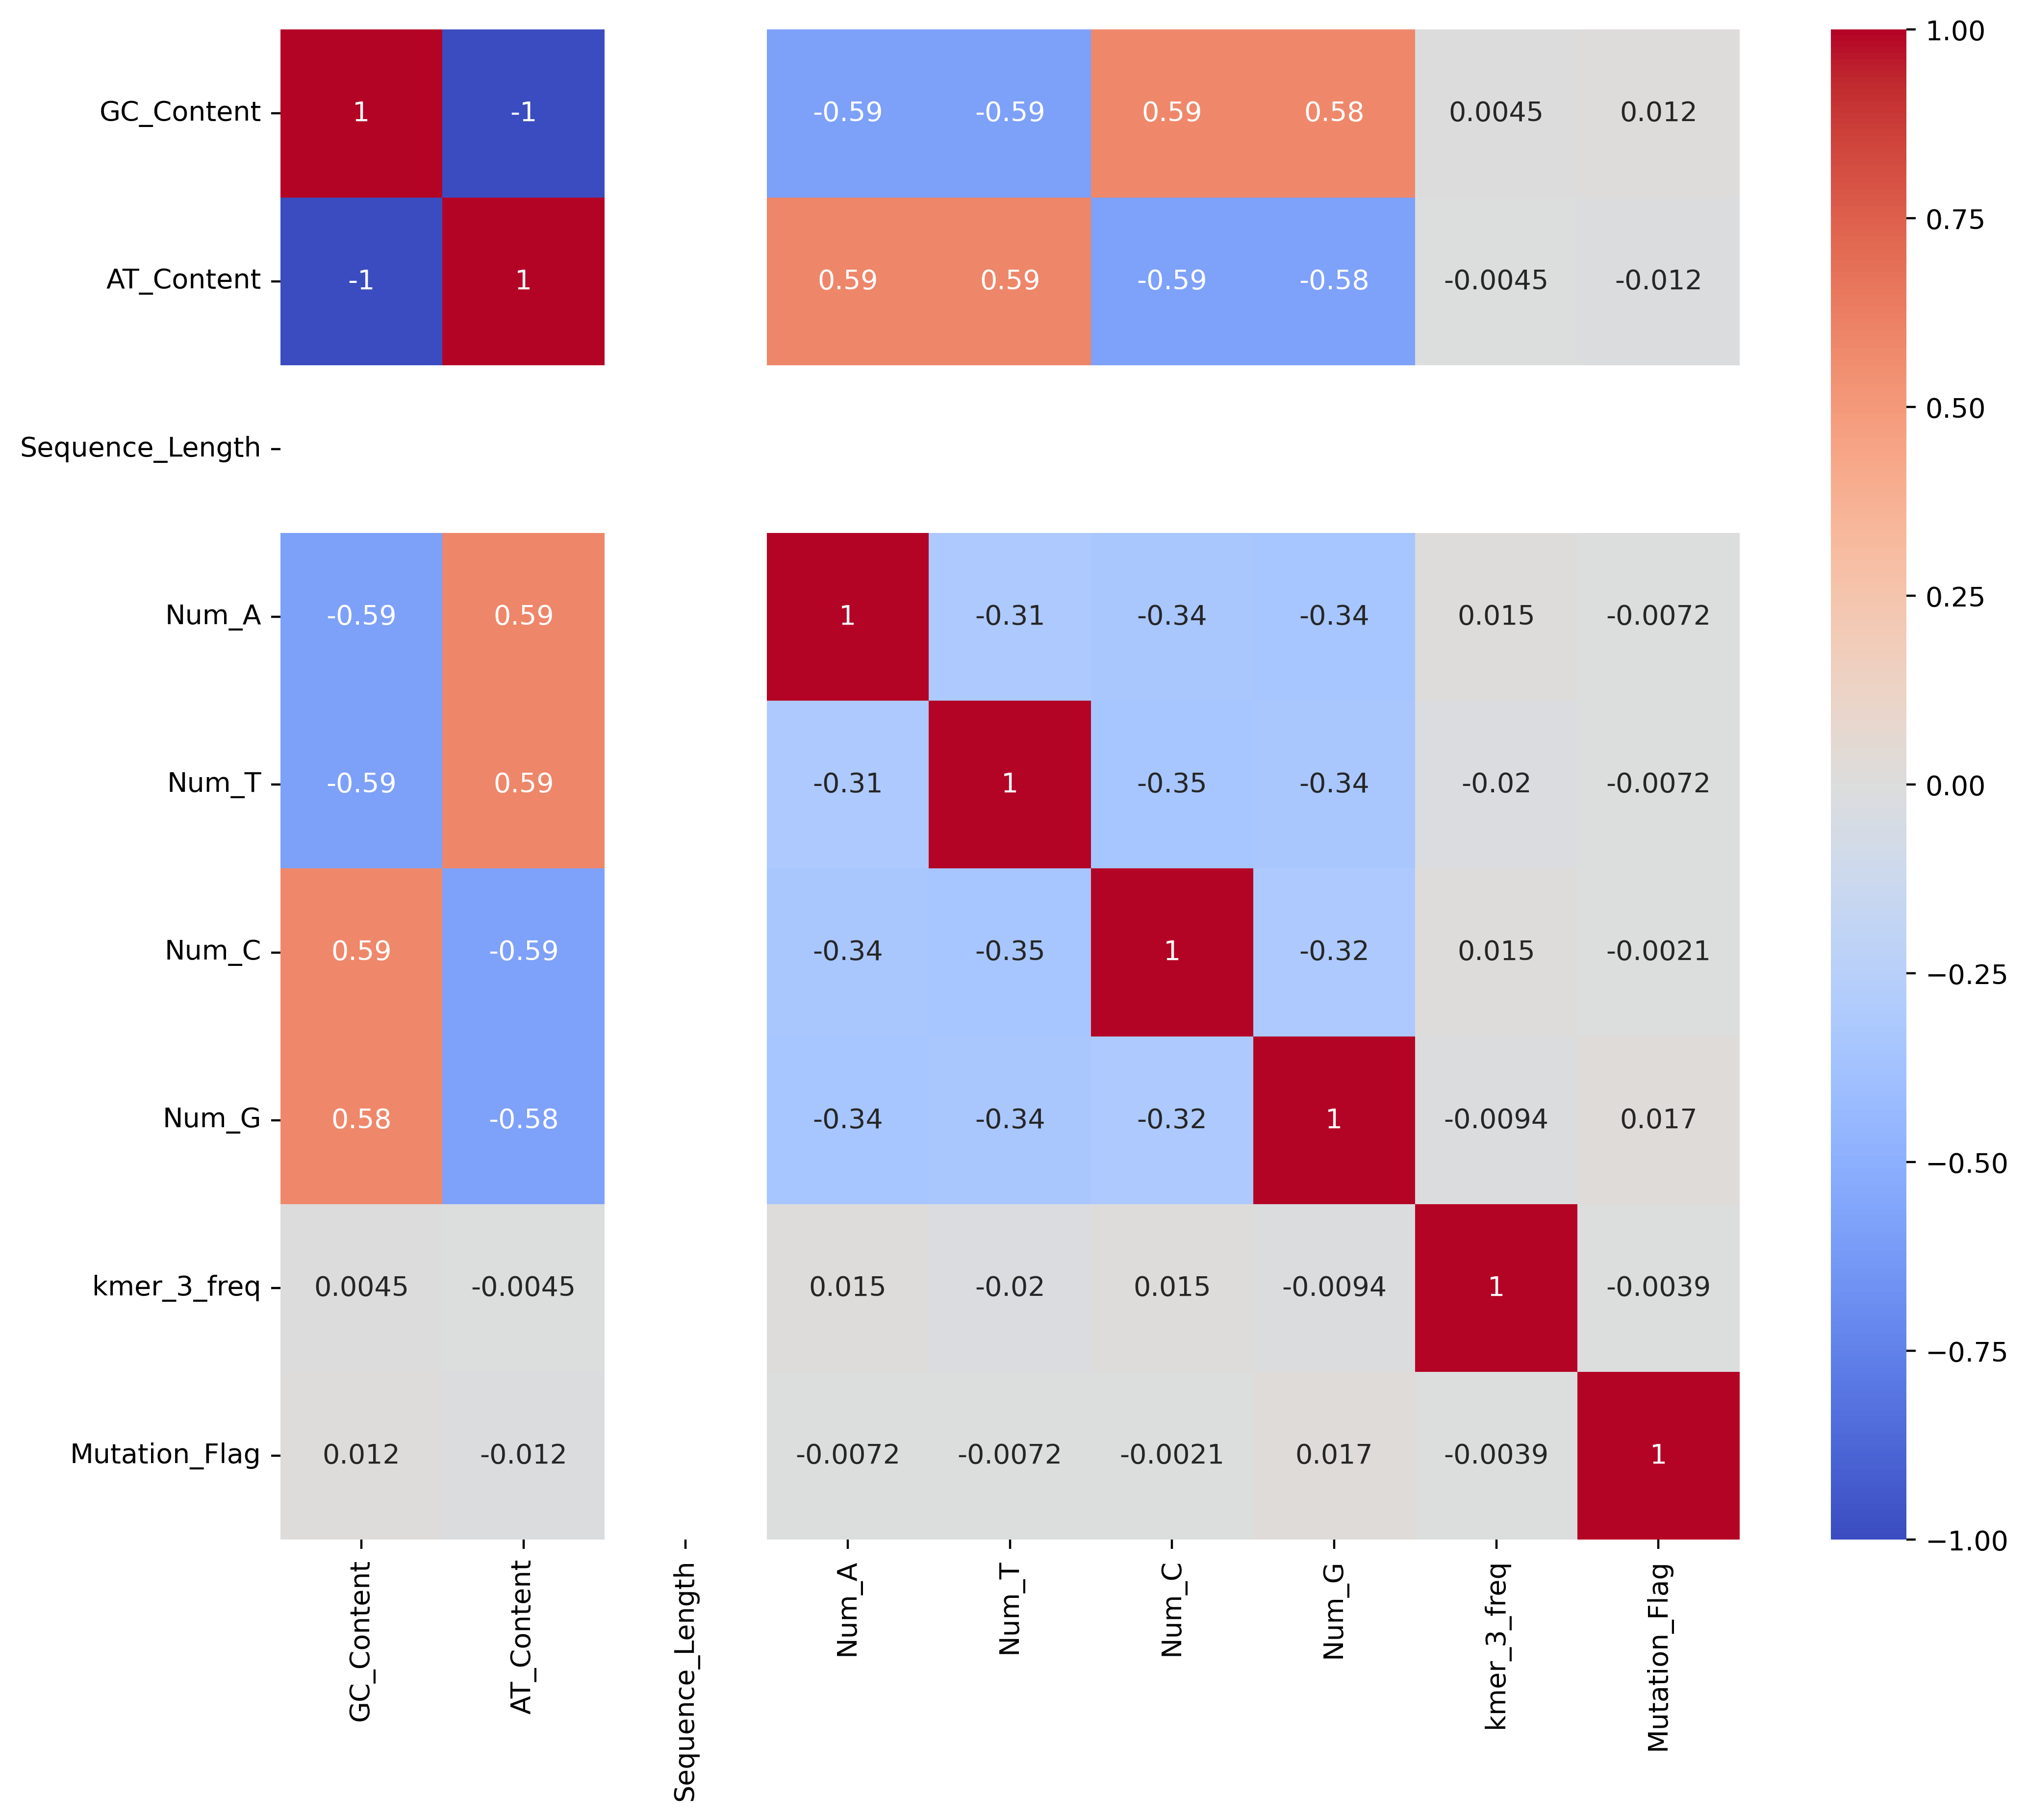

In [24]:
#heatmap für numeric columns
fig, ax = plt.subplots(figsize=(12, 10), dpi=400)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

In [13]:
#Distribution of data by Class_Label and Diese_Risk columns
print(df["Class_Label"].value_counts())
print(df["Disease_Risk"].value_counts())
print(df["Mutation_Flag"].value_counts())

Class_Label
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64
Disease_Risk
High      1046
Low        978
Medium     976
Name: count, dtype: int64
Mutation_Flag
0    1510
1    1490
Name: count, dtype: int64


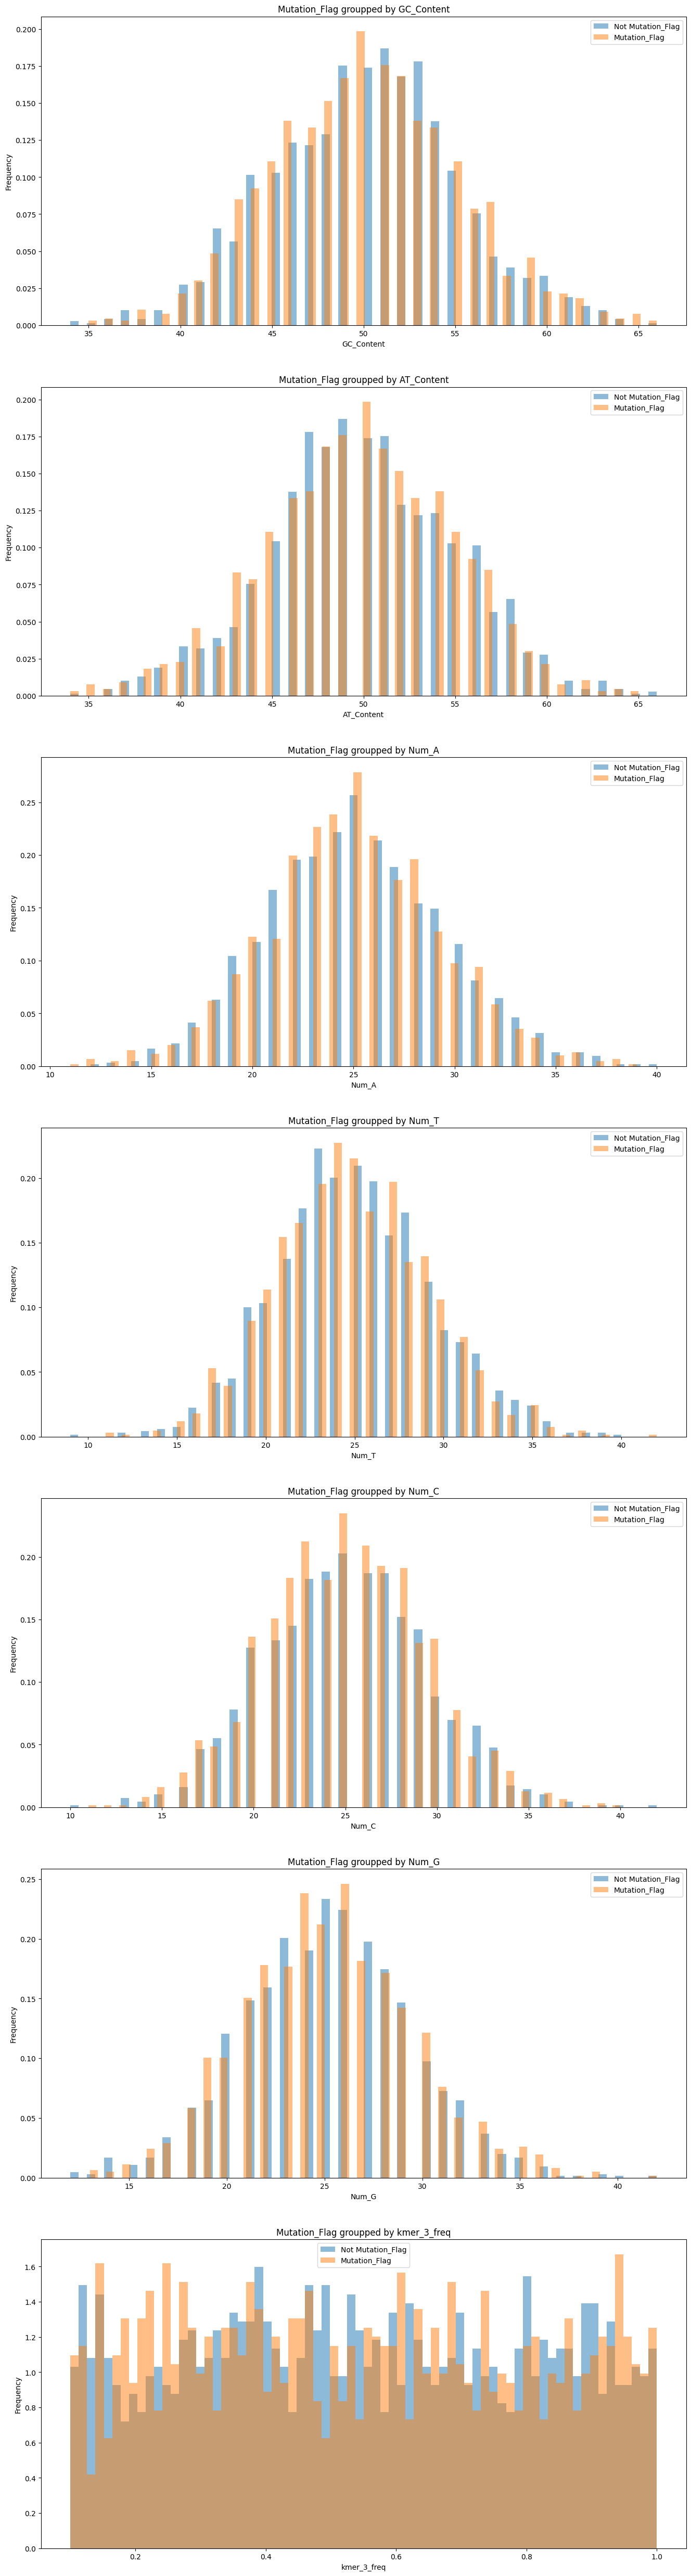

In [15]:
#create numeric columns without sequence_length and mautation_flag columns
numeric_columns = numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
selected_numeric_columns = [col for col in numeric_columns if col not in ['Sequence_Length', 'Mutation_Flag']]
#create digrams with Mutation_flag
fig, ax = plt.subplots(nrows=len(selected_numeric_columns), ncols=1, figsize=(16, 5*len(selected_numeric_columns)));
for i, column in enumerate(selected_numeric_columns):
    df.groupby('Mutation_Flag')[column].plot(kind='hist', ax=ax[i], legend=True, alpha=0.5, density=True, bins=70);
    ax[i].set_title(f'Mutation_Flag groupped by {column}');
    ax[i].xaxis.set_tick_params(labelrotation=0);
    ax[i].set_xlabel(column);
    ax[i].legend(['Not Mutation_Flag', 'Mutation_Flag'])
    ax[i].grid(False);
    
plt.suptitle("");
plt.subplots_adjust(top=1.5);
plt.tight_layout;  


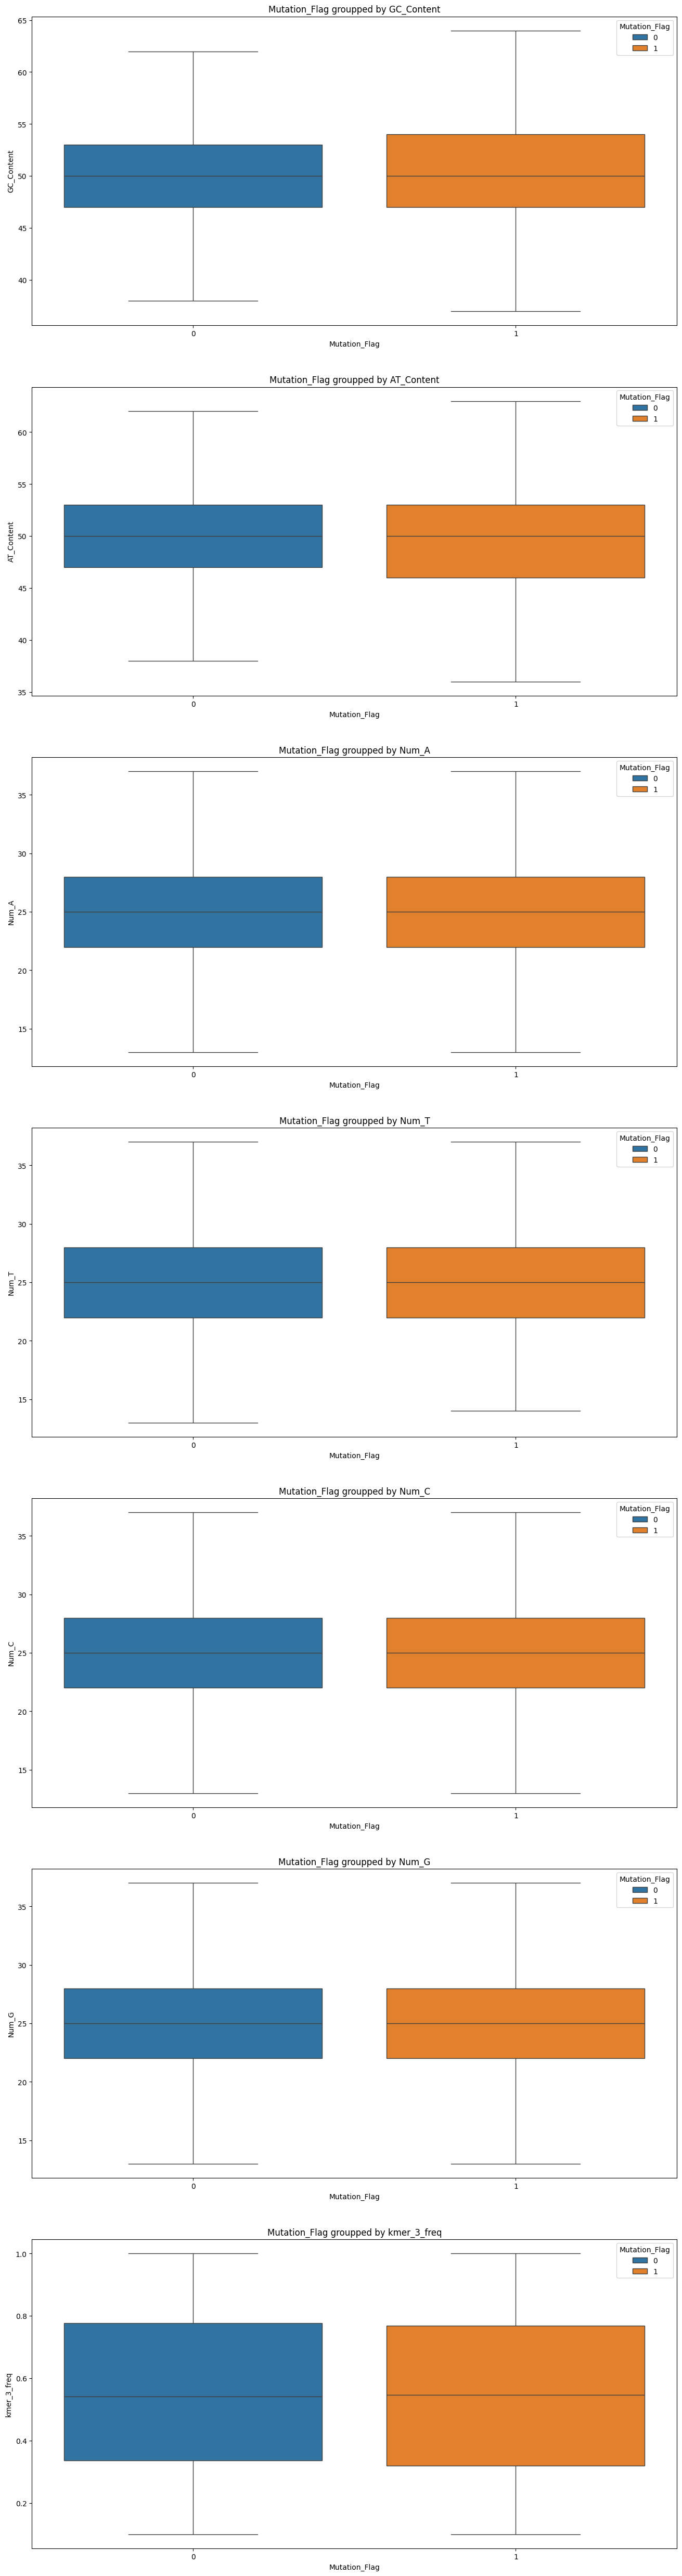

In [23]:
from re import X


fig, ax = plt.subplots(nrows=len(selected_numeric_columns), ncols=1, figsize=(16, 5*len(selected_numeric_columns)));
for i, column in enumerate(selected_numeric_columns):
    sns.boxplot(x='Mutation_Flag', y=column, data=df, ax=ax[i], showfliers=False, hue='Mutation_Flag')
    ax[i].set_title(f'Mutation_Flag groupped by {column}');
    ax[i].xaxis.set_tick_params(labelrotation=0);
    ax[i].set_xlabel('Mutation_Flag');
    ax[i].grid(False);
    
plt.suptitle("");
plt.subplots_adjust(top=1.5);
plt.tight_layout;  


C:\Users\yamen\AppData\Local\Temp\ipykernel_19524\3051325497.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]);


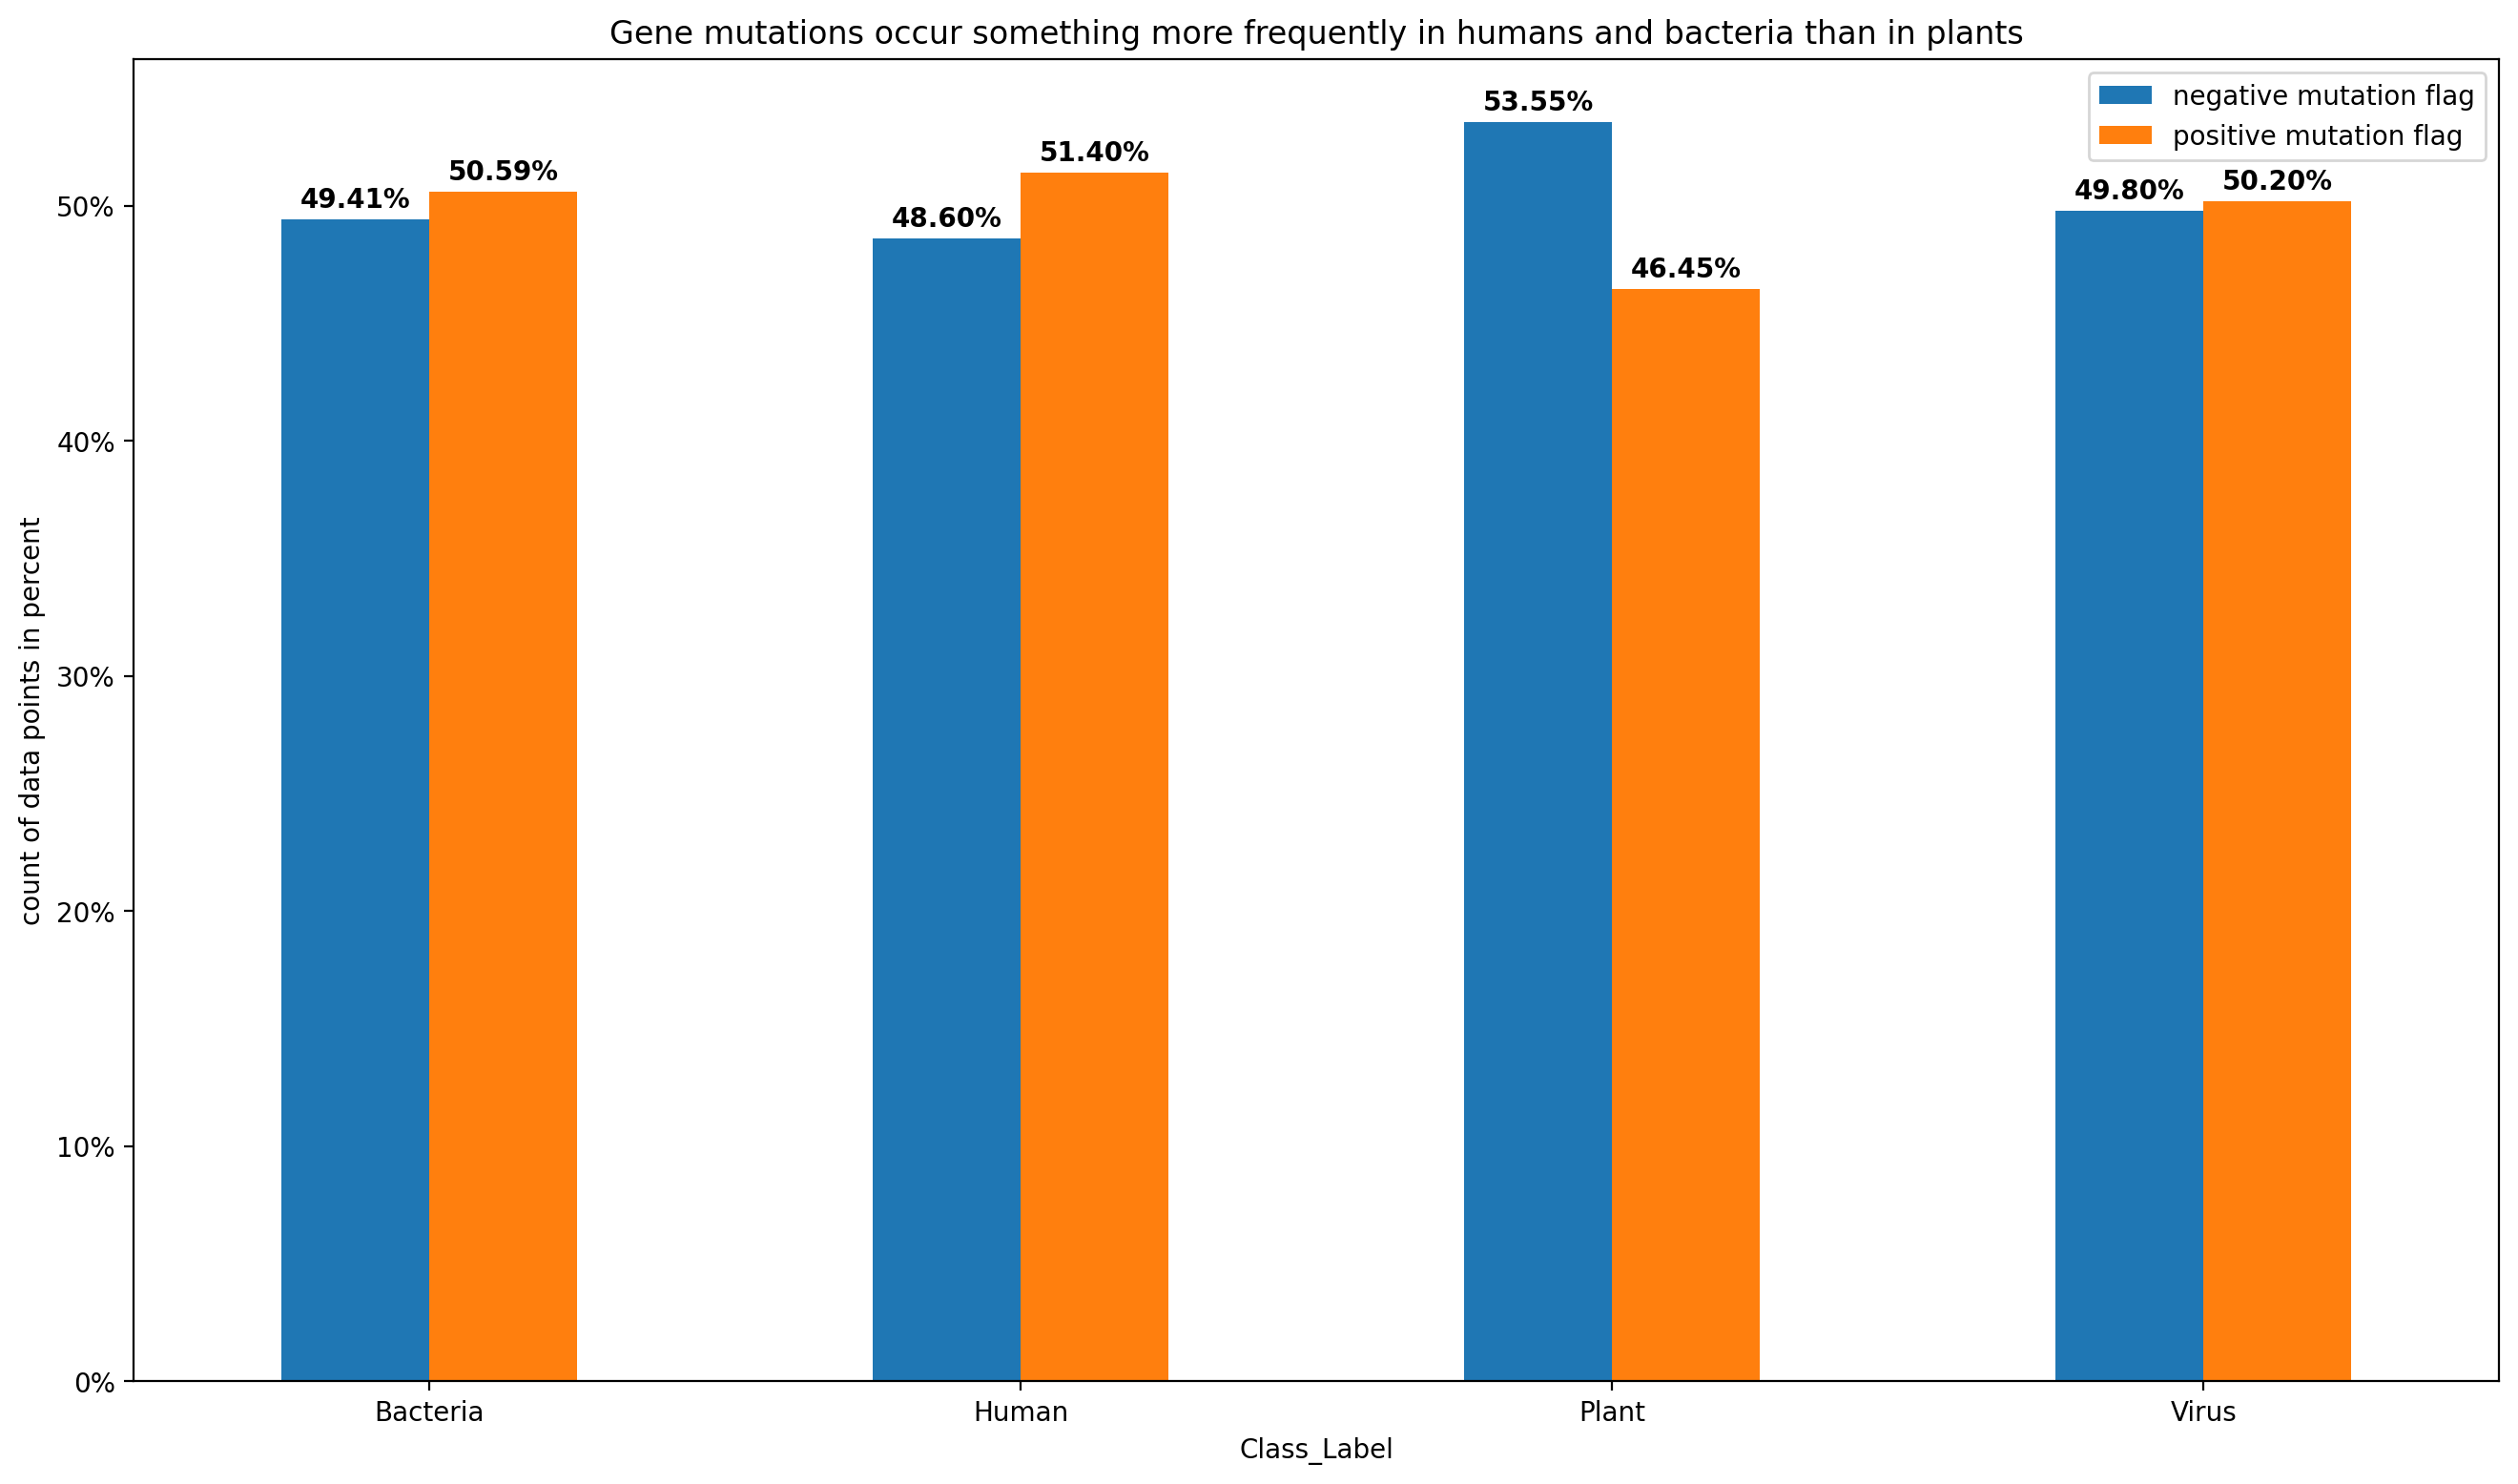

In [28]:
#Visualization of Class_Label with Mutation_flag
fig, ax=plt.subplots(figsize=(16, 9), dpi=200);
pd.crosstab(index=df['Class_Label'], columns=df["Mutation_Flag"], normalize="index").plot(kind="bar", ax=ax, legend=True);
plt.legend(framealpha=0.3);
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]); 
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.2%}",
        ha='center',
        fontweight='bold',
        fontsize=10
    );
ax.xaxis.set_tick_params(labelrotation=0);
ax.set(xlabel='Class_Label', ylabel='count of data points in percent', title='Gene mutations occur something more frequently in humans and bacteria than in plants');
ax.grid(False);
ax.legend(['negative mutation flag', 'positive mutation flag']);


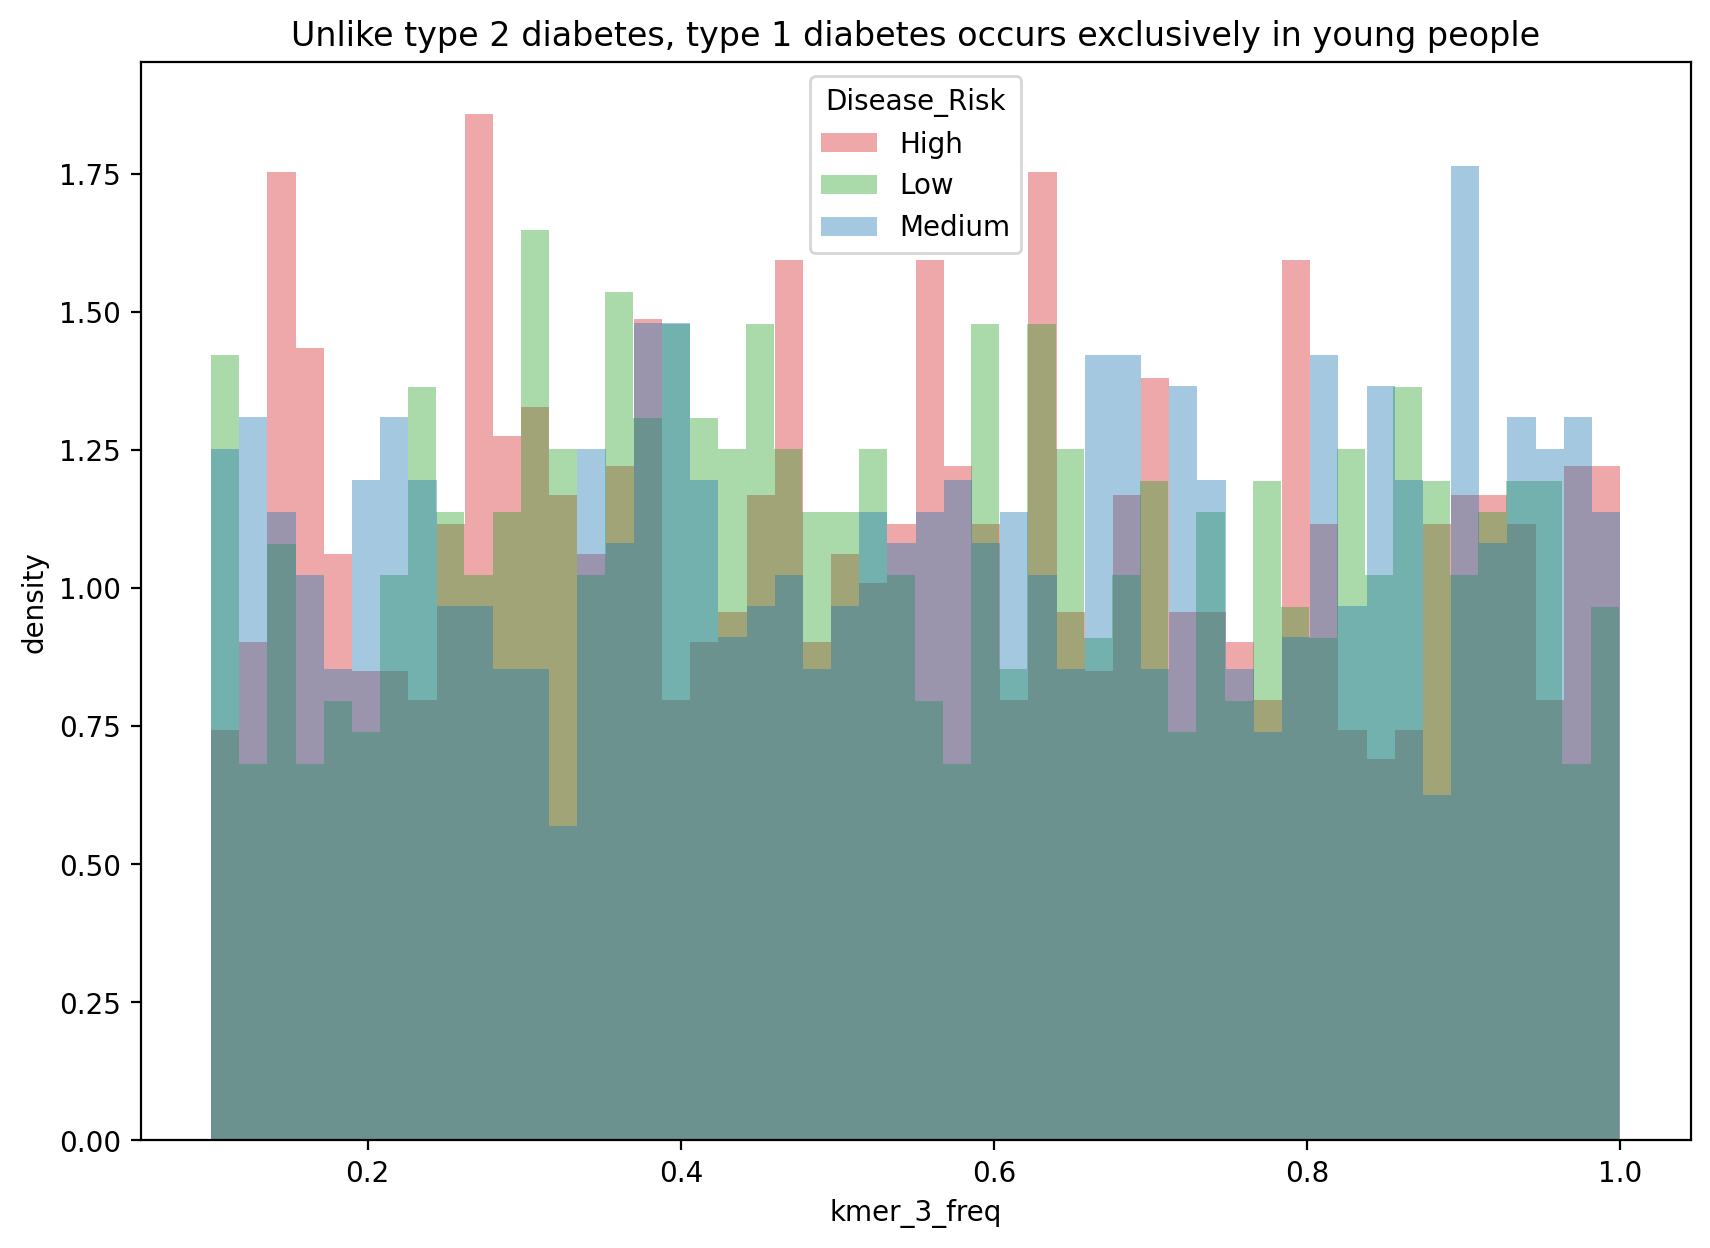

In [42]:
#Visualization of Disease_Risk with numeric columns by histogram
selected_stages = ['High', 'Medium', 'Low']
colors = {'High': 'tab:red', 'Medium': 'tab:blue', 'Low': 'tab:green'}
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
for stage, group in df.groupby('Disease_Risk'):
    if stage in selected_stages:
        group['kmer_3_freq'].plot(
            kind='hist',
            density=True,
            alpha=0.4,
            color=colors[stage],
            ax=ax,
            label=stage, legend=True, bins=50)

ax.set_xlabel('kmer_3_freq')
ax.set_ylabel('density')
ax.set_title('Unlike type 2 diabetes, type 1 diabetes occurs exclusively in young people')
ax.grid(False);
ax.legend(framealpha=0.005);
plt.legend(title='Disease_Risk')
plt.show()


array(['High', 'Medium', 'Low'], dtype=object)